<a href="https://colab.research.google.com/github/amanpoonia/Derivatives/blob/main/Backtesting_strat_mean_reversion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
tickers = ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOGL', 'META', 'TSLA']
start_date = '2020-01-01'
end_date = '2026-09-15'
data = yf.download(tickers, start_date, end_date)
prices = data['Close']
prices

/tmp/ipykernel_2015/3936366450.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start_date, end_date)
[*********************100%***********************]  7 of 7 completed


Ticker,AAPL,AMZN,GOOGL,META,MSFT,NVDA,TSLA
Date,,,,,,,
2020-01-02,72.271530,94.900497,67.788948,207.953857,151.544266,5.957138,28.684000
2020-01-03,71.568916,93.748497,67.434303,206.853516,149.657288,5.861787,29.534000
2020-01-06,72.139198,95.143997,69.231712,210.749313,150.044144,5.886370,30.102667
2020-01-07,71.799919,95.343002,69.097984,211.205307,148.676025,5.957634,31.270666
2020-01-08,72.954910,94.598503,69.589806,213.346466,151.044220,5.968808,32.809334
...,...,...,...,...,...,...,...
2026-09-08,316.220001,256.970001,338.359985,613.479980,493.950012,225.477692,368.160004
2026-09-09,315.339996,252.399994,330.649994,653.690002,491.649994,223.419998,367.809998
2026-09-10,326.570007,251.889999,332.600006,644.380005,492.440002,218.360001,363.559998


In [8]:
ret = np.log(prices/prices.shift(1))
#ret = prices.pct_change()
ret

Ticker,AAPL,AMZN,GOOGL,META,MSFT,NVDA,TSLA
Date,,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,-0.009769,-0.012213,-0.005245,-0.005305,-0.012530,-0.016136,0.029203
2020-01-06,0.007937,0.014776,0.026305,0.018658,0.002582,0.004185,0.019072
2020-01-07,-0.004714,0.002089,-0.001933,0.002161,-0.009160,0.012034,0.038067
2020-01-08,0.015958,-0.007839,0.007093,0.010087,0.015803,0.001874,0.048033
...,...,...,...,...,...,...,...
2026-09-08,-0.011789,-0.005975,-0.000296,-0.005349,-0.011574,-0.020304,0.038995
2026-09-09,-0.002787,-0.017944,-0.023050,0.063486,-0.004667,-0.009168,-0.000951
2026-09-10,0.034993,-0.002023,0.005880,-0.014345,0.001606,-0.022908,-0.011622


We have everyday return of the stock universe.

We buy the worst performing 2 stocks
and sell them the next day.

In [9]:
ret.columns

Index(['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA'], dtype='object', name='Ticker')

In [10]:
rank = ret.rank(axis=1, ascending=True)
rank.head()

Ticker,AAPL,AMZN,GOOGL,META,MSFT,NVDA,TSLA
Date,,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,4.0,3.0,6.0,5.0,2.0,1.0,7.0
2020-01-06,3.0,4.0,7.0,5.0,1.0,2.0,6.0
2020-01-07,2.0,4.0,3.0,5.0,1.0,6.0,7.0
2020-01-08,6.0,1.0,3.0,4.0,5.0,2.0,7.0


In [11]:
worst = rank[(rank == 1) | (rank == 2)].fillna(0)
worst

Ticker,AAPL,AMZN,GOOGL,META,MSFT,NVDA,TSLA
Date,,,,,,,
2020-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-03,0.0,0.0,0.0,0.0,2.0,1.0,0.0
2020-01-06,0.0,0.0,0.0,0.0,1.0,2.0,0.0
2020-01-07,2.0,0.0,0.0,0.0,1.0,0.0,0.0
2020-01-08,0.0,1.0,0.0,0.0,0.0,2.0,0.0
...,...,...,...,...,...,...,...
2026-09-08,2.0,0.0,0.0,0.0,0.0,1.0,0.0
2026-09-09,0.0,2.0,1.0,0.0,0.0,0.0,0.0
2026-09-10,0.0,0.0,0.0,2.0,0.0,1.0,0.0


In [7]:
# Identify the tickers with rank 1 or 2 (worst performers)
invest_in = rank[(rank == 1) | (rank == 2)].fillna(0)
invest_in.head()

bool_worst = invest_in.apply(lambda x: x>0).fillna(0)
bool_worst

#new_bool_worst = bool_worst.shift(1)
#new_bool_worst

#ret_bool_worst = (ret*bool_worst).fillna(0)
#ret_bool_worst.head()

Ticker,AAPL,AMZN,GOOGL,META,MSFT,NVDA,TSLA
Date,,,,,,,
2020-01-02,False,False,False,False,False,False,False
2020-01-03,False,False,False,False,True,True,False
2020-01-06,False,False,False,False,True,True,False
2020-01-07,True,False,False,False,True,False,False
2020-01-08,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...
2026-09-08,True,False,False,False,False,True,False
2026-09-09,False,True,True,False,False,False,False
2026-09-10,False,False,False,True,False,True,False


Lets shift returns by 1 day upwards

In [23]:
retxbool = ret.shift(-1)*bool_worst
retxbool.head()

Ticker,AAPL,AMZN,GOOGL,META,MSFT,NVDA,TSLA
Date,,,,,,,
2020-01-02,-0.000000,-0.000000,-0.0,-0.0,-0.000000,-0.000000,0.0
2020-01-03,0.000000,0.000000,0.0,0.0,0.002582,0.004185,0.0
2020-01-06,-0.000000,0.000000,-0.0,0.0,-0.009160,0.012034,0.0
2020-01-07,0.015958,-0.000000,0.0,0.0,0.015803,0.000000,0.0
2020-01-08,0.000000,0.004788,0.0,0.0,0.000000,0.010923,-0.0


In [19]:
portfolio_v0 = 100
no_worst_to_invest = 2
weight = 1/no_worst_to_invest


In [31]:
ret_daily = retxbool.sum(axis=1)/no_worst_to_invest
ret_daily.head()
ret_daily = ret_daily[1:]
ret_daily

,0
Date,
2020-01-03,0.003383
2020-01-06,0.001437
2020-01-07,0.015881
2020-01-08,0.007855
2020-01-09,-0.008052
...,...
2026-09-08,-0.005977
2026-09-09,0.001929
2026-09-10,0.002664


In [33]:
portfolio_ret = ret_daily.cumsum()
portfolio_value = portfolio_v0 * (1 + portfolio_ret)
portfolio_value

,0
Date,
2020-01-03,100.338330
2020-01-06,100.482035
2020-01-07,102.070098
2020-01-08,102.855625
2020-01-09,102.050399
...,...
2026-09-08,332.906471
2026-09-09,333.099349
2026-09-10,333.365737


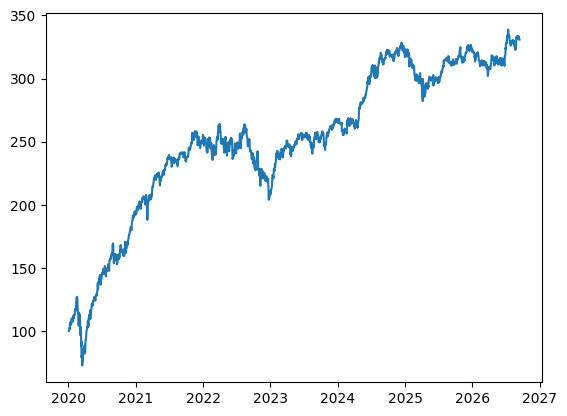

In [35]:
plt.plot(portfolio_value)

In [47]:
portfolio_value.mean()

np.float64(251.48094091378687)

In [51]:
sharpe = ret_daily.mean()/ret_daily.std()
sharpe

np.float64(0.055488254591108364)

Compare with S&P

In [56]:
sp = yf.download('^GSPC', start_date, end_date)
sp_prices = sp['Close']
sp_prices

/tmp/ipykernel_2015/4127108261.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp = yf.download('^GSPC', start_date, end_date)
[*********************100%***********************]  1 of 1 completed


Ticker,^GSPC
Date,
2020-01-02,3257.850098
2020-01-03,3234.850098
2020-01-06,3246.280029
2020-01-07,3237.179932
2020-01-08,3253.050049
...,...
2026-09-08,7673.520020
2026-09-09,7636.359863
2026-09-10,7591.700195


In [57]:
sp_daily_ret = np.log(sp_prices/sp_prices.shift(1))
sp_daily_ret

Ticker,^GSPC
Date,
2020-01-02,NaN
2020-01-03,-0.007085
2020-01-06,0.003527
2020-01-07,-0.002807
2020-01-08,0.004890
...,...
2026-09-08,-0.005858
2026-09-09,-0.004854
2026-09-10,-0.005865


In [59]:
sp_value = sp_daily_ret.cumsum()
sp_value

Ticker,^GSPC
Date,
2020-01-02,NaN
2020-01-03,-0.007085
2020-01-06,-0.003558
2020-01-07,-0.006365
2020-01-08,-0.001474
...,...
2026-09-08,0.856708
2026-09-09,0.851854
2026-09-10,0.845988


In [60]:
sp_port_val = portfolio_v0*(1+sp_value)
sp_port_val

Ticker,^GSPC
Date,
2020-01-02,NaN
2020-01-03,99.291509
2020-01-06,99.644224
2020-01-07,99.363506
2020-01-08,99.852553
...,...
2026-09-08,185.670794
2026-09-09,185.185353
2026-09-10,184.598807


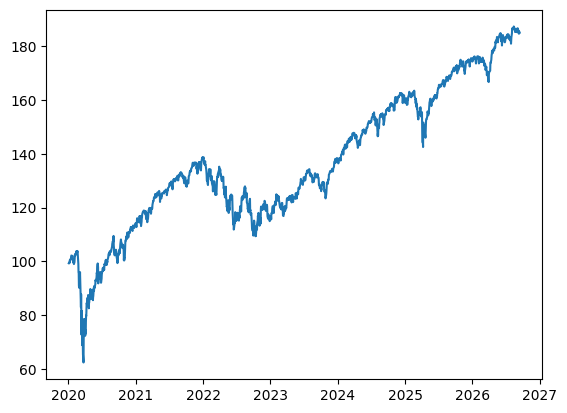

In [61]:
plt.plot(sp_port_val)

In [58]:
sp_sharpe = sp_daily_ret.mean()/sp_daily_ret.std()
sp_sharpe

,0
Ticker,
^GSPC,0.039462


**GEMINIS WORK BELOW**

In [13]:
ret.shift(-1)

Ticker,AAPL,AMZN,GOOGL,META,MSFT,NVDA,TSLA
Date,,,,,,,
2020-01-02,-0.009769,-0.012213,-0.005245,-0.005305,-0.012530,-0.016136,0.029203
2020-01-03,0.007937,0.014776,0.026305,0.018658,0.002582,0.004185,0.019072
2020-01-06,-0.004714,0.002089,-0.001933,0.002161,-0.009160,0.012034,0.038067
2020-01-07,0.015958,-0.007839,0.007093,0.010087,0.015803,0.001874,0.048033
2020-01-08,0.021019,0.004788,0.010443,0.014210,0.012415,0.010923,-0.022189
...,...,...,...,...,...,...,...
2026-09-08,-0.002787,-0.017944,-0.023050,0.063486,-0.004667,-0.009168,-0.000951
2026-09-09,0.034993,-0.002023,0.005880,-0.014345,0.001606,-0.022908,-0.011622
2026-09-10,0.017304,0.019227,0.017584,0.005648,0.006457,-0.000321,0.005158


### Calculating Returns for Next Day's Investment
To correctly simulate investing in the worst performing stocks of day `t` and realizing their returns on day `t+1`, we need to shift the `ret` (returns) DataFrame. Then, we apply the `bool_worst` mask to these shifted returns. This effectively gives us the returns *earned* by our daily investment decisions.

In [ ]:
# Shift the returns by one day to align with next day's returns
shifted_ret = ret.shift(-1)

# Multiply the boolean mask by the shifted returns.
# This will keep the next day's returns for the selected 'worst' stocks
# and set others to NaN or 0 (depending on how fillna is applied later).
ret_for_investment = shifted_ret * bool_worst

# Display the head of the DataFrame to see the effect
display(ret_for_investment.head())

equally weighted investment

In [16]:
portfolio_v0 = 100
no_worst_to_invest = 2
weight = 1/no_worst_to_invest



### Identify Worst Performing Stocks and Calculate Portfolio Returns
Based on the daily ranks, we'll identify the two worst-performing stocks (rank 1 and 2) for each day and calculate the portfolio return for that day by investing equally in them.

In [17]:
# Calculate daily portfolio returns by summing the returns of the selected stocks (from retxbool)
# and dividing by the number of stocks invested in (for equal weighting).
daily_portfolio_returns = retxbool.sum(axis=1) / no_worst_to_invest

# Drop any NaN values that might result from the shifting or initial NaNs in returns
daily_portfolio_returns = daily_portfolio_returns.dropna()

display(daily_portfolio_returns.head())

,0
Date,
2020-01-02,0.000000
2020-01-03,0.003383
2020-01-06,0.001437
2020-01-07,0.015881
2020-01-08,0.007855


### Track Portfolio Value
Now, let's update the initial portfolio value (`portfolio_v0`) daily using the calculated `daily_portfolio_returns`.

In [59]:
# Initialize portfolio value
portfolio_value = pd.Series(index=daily_portfolio_returns.index)
portfolio_value.iloc[0] = portfolio_v0 * (1 + daily_portfolio_returns.iloc[0])

# Calculate the cumulative portfolio value
for i in range(1, len(daily_portfolio_returns)):
    portfolio_value.iloc[i] = portfolio_value.iloc[i-1] * (1 + daily_portfolio_returns.iloc[i])


display(portfolio_value.tail())

,0
Date,
2026-09-08,8.965463e-11
2026-09-09,8.781697e-11
2026-09-10,8.618125e-11
2026-09-11,8.638969e-11
2026-09-14,8.414273e-11


### Visualize Portfolio Performance
Let's plot the portfolio value over time to see its performance.

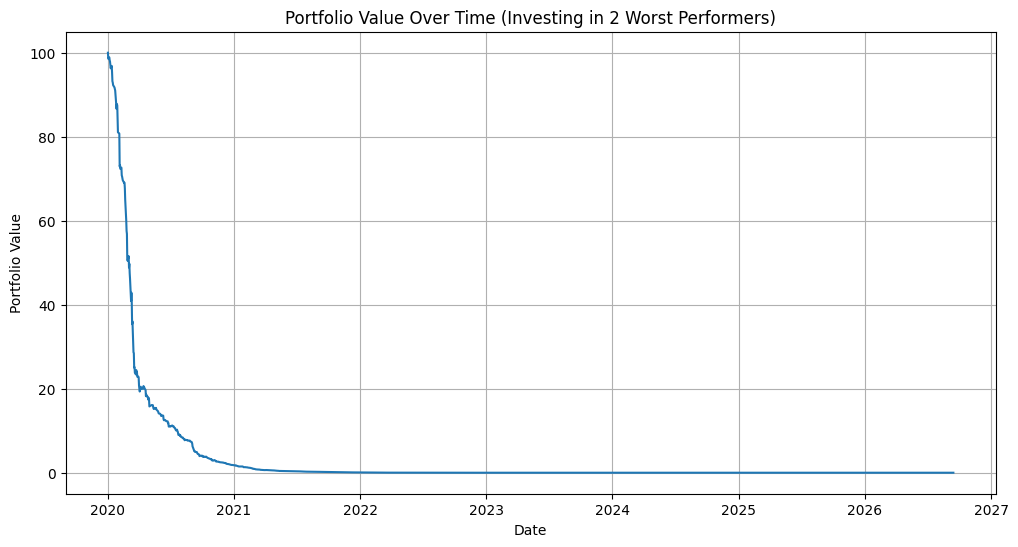

In [60]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 6))
plt.plot(portfolio_value.index, portfolio_value.values)
plt.title('Portfolio Value Over Time (Investing in 2 Worst Performers)')
plt.xlabel('Date')
plt.ylabel('Portfolio Value')
plt.grid(True)
plt.show()

How we invest:

1) the top 2 in the rank get the money.

In [36]:
help(yf.download)

Help on function download in module yfinance.multi:

download(
    tickers,
    start=None,
    end=None,
    actions=False,
    threads=True,
    ignore_tz=None,
    group_by='column',
    auto_adjust=None,
    back_adjust=False,
    repair=False,
    keepna=False,
    progress=True,
    period=None,
    interval='1d',
    prepost=False,
    proxy=<object object at 0x7d31cf2d6260>,
    rounding=False,
    timeout=10,
    session=None,
    multi_level_index=True
) -> Optional[pandas.core.frame.DataFrame]
    Download yahoo tickers
    :Parameters:
        tickers : str, list
            List of tickers to download
        period : str
            Valid periods: 1d,5d,1mo,3mo,6mo,1y,2y,5y,10y,ytd,max
            Default: 1mo
            Either Use period parameter or use start and end
        interval : str
            Valid intervals: 1m,2m,5m,15m,30m,60m,90m,1h,1d,5d,1wk,1mo,3mo
            Intraday data cannot extend last 60 days
        start: str
            Download start date str

AAPL  AMZN  GOOGL  META  MSFT  NVDA  TSLA
5.0   3.0   4.0    2.0   6.0   7.0   1.0     6
7.0   4.0   5.0    3.0   6.0   1.0   2.0     6
6.0   2.0   3.0    4.0   5.0   1.0   7.0     5
5.0   1.0   3.0    2.0   4.0   6.0   7.0     5
4.0   2.0   3.0    5.0   6.0   7.0   1.0     5
                                            ..
3.0   6.0   4.0    2.0   7.0   5.0   1.0     1
                         1.0   5.0   7.0     1
                   1.0   7.0   5.0   2.0     1
                         2.0   7.0   5.0     1
                   7.0   5.0   2.0   1.0     1
Name: count, Length: 1279, dtype: int64